In [14]:
import pandas as pd

DATA_PATH = "../data/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
df["temperature_difference"] = (df["Process temperature [K]"]-df["Air temperature [K]"])

df["power_proxy"] = (df["Torque [Nm]"] * df["Rotational speed [rpm]"])

df[[
    "Air temperature [K]",
    "Process temperature [K]",
    "temperature_difference",
    "Torque [Nm]",
    "Rotational speed [rpm]",
    "power_proxy",
    "Machine failure",
]].head()

,Air temperature [K],Process temperature [K],temperature_difference,Torque [Nm],Rotational speed [rpm],power_proxy,Machine failure
0,298.1,308.6,10.5,42.8,1551,66382.8,0
1,298.2,308.7,10.5,46.3,1408,65190.4,0
2,298.1,308.5,10.4,49.4,1498,74001.2,0
3,298.2,308.6,10.4,39.5,1433,56603.5,0
4,298.2,308.7,10.5,40.0,1408,56320.0,0


In [16]:
engineered_features = ["temperature_difference", "power_proxy"]
df.groupby("Machine failure")[engineered_features].mean()

,temperature_difference,power_proxy
Machine failure,,
0,10.021571,59631.036446
1,9.403835,69545.803245


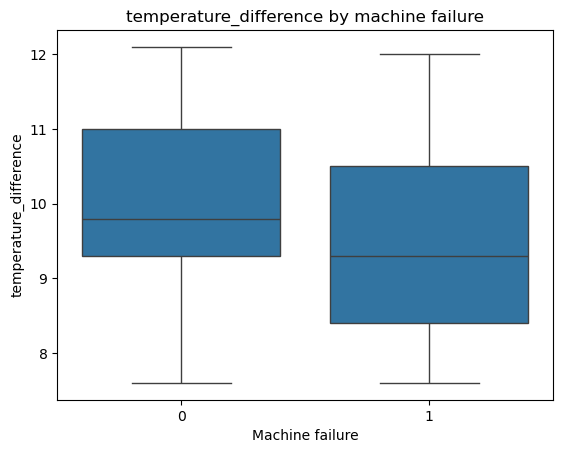

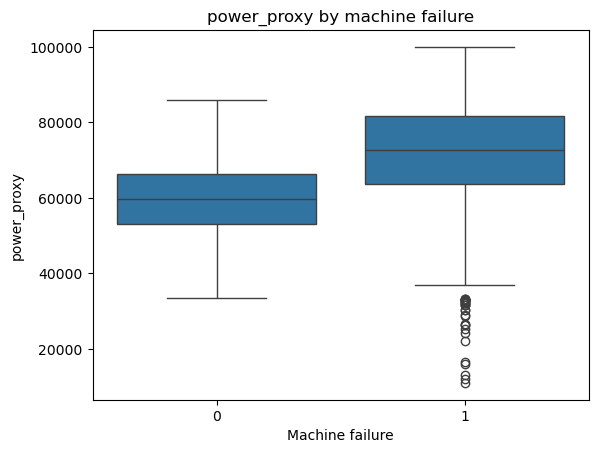

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in engineered_features:
    sns.boxplot(data=df, x="Machine failure", y=col)
    plt.title(f"{col} by machine failure")
    plt.show()

- Power proxy is higher for failed machins on average. It looks more useful.
- Temperature difference does not separate failures clearly. 

In [18]:
base_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
engineered_feature_cols = base_features + ["temperature_difference","power_proxy"]

target_col = "Machine failure"

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

In [20]:
import sys
sys.path.append("../src")
from machineguard.modeling import build_random_forest_model

In [21]:
def calculate_metrics(y_true, y_pred):
    return{
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),        
    }

In [22]:
X_base = df[base_features]
X_engineered = df[engineered_feature_cols]
y = df[target_col]

In [23]:
X_base_train_full, X_base_test, X_eng_train_full, X_eng_test, y_train_full, y_test = train_test_split(
    X_base, 
    X_engineered,
    y,
    test_size=0.2,
    random_state=12,
    stratify=y
)
X_base_train, X_base_val, X_eng_train, X_eng_val, y_train, y_val = train_test_split(
    X_base_train_full,
    X_eng_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

In [24]:
base_model = build_random_forest_model(base_features)
engineered_model = build_random_forest_model(engineered_feature_cols)

base_model.fit(X_base_train, y_train)
engineered_model.fit(X_eng_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('category', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
threshold = 0.3

base_val_prob = base_model.predict_proba(X_base_val)[:,1]
engineered_val_prob = engineered_model.predict_proba(X_eng_val)[:,1]

base_val_predictions = (base_val_prob >= threshold).astype(int)
engineered_val_predictions = (engineered_val_prob >= threshold).astype(int)

base_metrics = calculate_metrics(y_val, base_val_predictions)
engineered_metrics = calculate_metrics(y_val, engineered_val_predictions)

pd.DataFrame(
    [base_metrics, engineered_metrics],
    index=["Base features", "Engineered features"]
)

,accuracy,precision,recall,f1
Base features,0.9790,0.709677,0.647059,0.676923
Engineered features,0.9905,0.888889,0.823529,0.854962


In [27]:
base_matrix = confusion_matrix(y_val, base_val_predictions)
engineered_matrix = confusion_matrix(y_val, engineered_val_predictions)

print("Base features")
print(base_matrix)

print("\nEngineered features")
print(engineered_matrix)

Base features
[[1914   18]
 [  24   44]]

Engineered features
[[1925    7]
 [  12   56]]


- F1 increased, recall increased. The confusion matrix also improved.
- This suggests that engineered features adds useful info.

- Next step - evaluate engineered model on test set.

In [29]:
engineered_test_prob = engineered_model.predict_proba(X_eng_test)[:, 1]
engineered_test_predictions = (engineered_test_prob >= threshold).astype(int)

engineered_test_metrics = calculate_metrics(y_test, engineered_test_predictions)
engineered_test_matrix = confusion_matrix(y_test, engineered_test_predictions)

print(engineered_test_metrics)
print(engineered_test_matrix)

{'accuracy': 0.9895, 'precision': 0.873015873015873, 'recall': 0.8088235294117647, 'f1': 0.8396946564885496}
[[1924    8]
 [  13   55]]


- Engineered model also performs well on the test set.
- F1=0.84, recall=0.81. Confusion matrix shows that it chatches 55 out of 68 failures, with only 8 false alarms.